In [2]:
import os

dataset_path = r"C:\Users\OM\Downloads\archive (4)\NEU-DET\train\images"

classes = os.listdir(dataset_path)

print("Classes:")
for cls in classes:
    print(cls)

Classes:
crazing
inclusion
patches
pitted_surface
rolled-in_scale
scratches


In [3]:
import os

dataset_path = r"C:\Users\OM\Downloads\archive (4)\NEU-DET\train\images"

classes = os.listdir(dataset_path)

for cls in classes:
    class_path = os.path.join(dataset_path, cls)
    images = os.listdir(class_path)

    print(cls, ":", len(images), "images")

crazing : 240 images
inclusion : 240 images
patches : 240 images
pitted_surface : 240 images
rolled-in_scale : 240 images
scratches : 240 images


In [4]:
from PIL import Image
import os

dataset_path = r"C:\Users\OM\Downloads\archive (4)\NEU-DET\train\images"

# Choose one class
class_name = "patches"

# Go to that class folder
class_path = os.path.join(dataset_path, class_name)

# Get image files
images = os.listdir(class_path)

# Take first image
image_name = images[0]

# Full image path
image_path = os.path.join(class_path, image_name)

# Load image
image = Image.open(image_path)

print("Image name:", image_name)
print("Image size:", image.size)
print("Image mode:", image.mode)

# Display image
image.show()

Image name: patches_1.jpg
Image size: (200, 200)
Image mode: RGB


In [5]:
import numpy as np

image_array = np.array(image)

print("Array shape:", image_array.shape)
print("Data type:", image_array.dtype)

print("First pixel:", image_array[0, 0])
print("First 5 pixels:")
print(image_array[0, :5])

Array shape: (200, 200, 3)
Data type: uint8
First pixel: [213 213 213]
First 5 pixels:
[[213 213 213]
 [215 215 215]
 [234 234 234]
 [228 228 228]
 [243 243 243]]


In [6]:
import sys
print(sys.executable)



c:\Users\OM\AppData\Local\Programs\Python\Python313\python.exe


In [7]:
%pip install torch torchvision

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
from torchvision import datasets, transforms

transform = transforms.ToTensor()

dataset = datasets.ImageFolder(
    root=r"C:\Users\OM\Downloads\archive (4)\NEU-DET\train\images",
    transform=transform
)

print("Classes:", dataset.classes)
print("Number of images:", len(dataset))

Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Number of images: 1440


In [9]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels)

Images shape: torch.Size([32, 3, 200, 200])
Labels shape: torch.Size([32])
Labels: tensor([2, 2, 0, 0, 4, 2, 2, 4, 0, 5, 2, 5, 5, 1, 2, 2, 3, 3, 0, 2, 3, 3, 2, 5,
        0, 5, 5, 4, 5, 2, 3, 4])


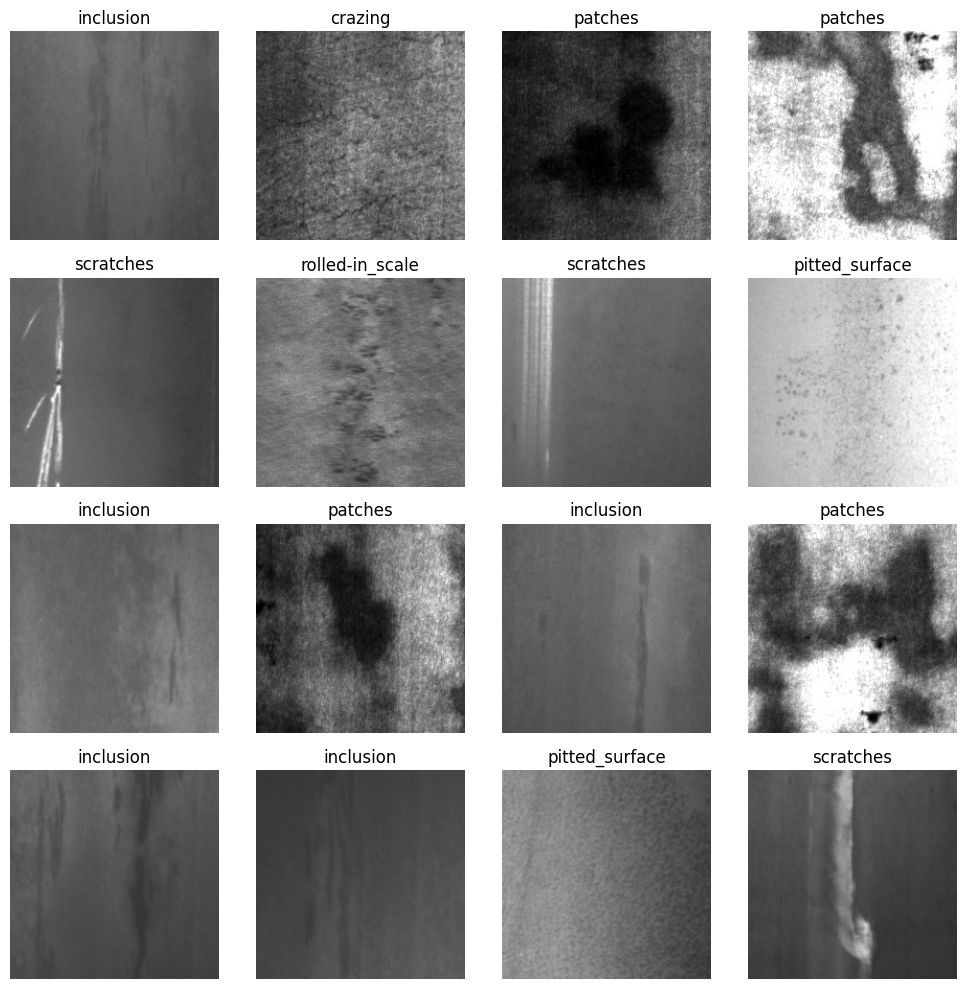

In [10]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 10))

for i in range(16):
    plt.subplot(4, 4, i + 1)

    # CHW → HWC for matplotlib
    img = images[i].permute(1, 2, 0)

    plt.imshow(img)
    plt.title(dataset.classes[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
import torch
import torch.nn as nn

In [56]:
class SimpleCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            # First convolution
            nn.Conv2d(
                in_channels=3,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2),

            # Second convolution
            nn.Conv2d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(32 * 50 * 50, 128),

            nn.ReLU(),

            nn.Linear(128, 6)
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [57]:
model = SimpleCNN()

outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)
print(outputs[0])

Input shape: torch.Size([8, 3, 200, 200])
Output shape: torch.Size([8, 6])
tensor([-0.1079, -0.0332, -0.0084, -0.0566, -0.0836,  0.0624],
       grad_fn=<SelectBackward0>)


In [58]:
criterion = nn.CrossEntropyLoss()

loss = criterion(outputs, labels)

print("Loss:", loss.item())

Loss: 1.6994154453277588


In [59]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [60]:
optimizer.zero_grad()

outputs = model(images)

loss = criterion(outputs, labels)

loss.backward()

optimizer.step()

print("Loss:", loss.item())

Loss: 1.6994154453277588


In [61]:
# Get a fresh batch
images, labels = next(iter(train_loader))

# New prediction using updated weights
outputs = model(images)

# Calculate new loss
new_loss = criterion(outputs, labels)

print("New loss:", new_loss.item())

New loss: 12.915138244628906


In [62]:
num_epochs = 10

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        # 1. Forward pass
        outputs = model(images)

        # 2. Calculate loss
        loss = criterion(outputs, labels)

        # 3. Clear old gradients
        optimizer.zero_grad()

        # 4. Backpropagation
        loss.backward()

        # 5. Update weights
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    print(
        f"Epoch [{epoch+1}/{num_epochs}], "
        f"Loss: {epoch_loss:.4f}"
    )

Epoch [1/10], Loss: 2.0747
Epoch [2/10], Loss: 1.0074
Epoch [3/10], Loss: 0.7075
Epoch [4/10], Loss: 0.4335
Epoch [5/10], Loss: 0.3368
Epoch [6/10], Loss: 0.3322
Epoch [7/10], Loss: 0.2660
Epoch [8/10], Loss: 0.2275
Epoch [9/10], Loss: 0.1777
Epoch [10/10], Loss: 0.1403


In [63]:
val_path = r"C:\Users\OM\Downloads\archive (4)\NEU-DET\validation\images"

val_dataset = datasets.ImageFolder(
    root=val_path,
    transform=transforms.ToTensor()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

print("Validation images:", len(val_dataset))
print("Classes:", val_dataset.classes)

Validation images: 360
Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


In [64]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 85.28%


Predicted class: crazing


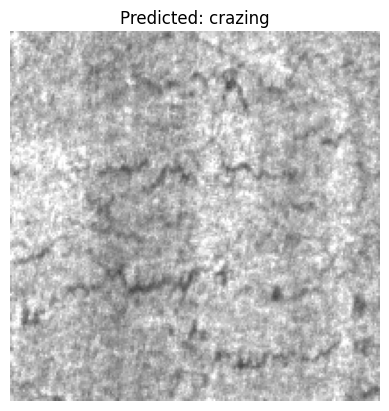

In [50]:
from PIL import Image
import torch
from torchvision import transforms
import matplotlib.pyplot as plt

# Path to the image
image_path = r"C:\Users\OM\Downloads\archive (4)\NEU-DET\validation\images\crazing\crazing_241.jpg"

# Class names
class_names = [
    'crazing',
    'inclusion',
    'patches',
    'pitted_surface',
    'rolled-in_scale',
    'scratches'
]

# Load image
image = Image.open(image_path).convert("RGB")

# Convert image to tensor
transform = transforms.ToTensor()
image_tensor = transform(image)

# Add batch dimension
image_tensor = image_tensor.unsqueeze(0)

# Prediction
model.eval()

with torch.no_grad():
    output = model(image_tensor)

    predicted_class = torch.argmax(output, dim=1).item()

# Show result
print("Predicted class:", class_names[predicted_class])

plt.imshow(image)
plt.title(f"Predicted: {class_names[predicted_class]}")
plt.axis("off")
plt.show()

In [65]:
from sklearn.metrics import classification_report, confusion_matrix

model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in val_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.numpy())
        all_predictions.extend(predicted.numpy())

In [66]:
class_names = [
    'crazing',
    'inclusion',
    'patches',
    'pitted_surface',
    'rolled-in_scale',
    'scratches'
]

print(classification_report(
    all_labels,
    all_predictions,
    target_names=class_names
))

                 precision    recall  f1-score   support

        crazing       1.00      0.93      0.97        60
      inclusion       0.91      0.50      0.65        60
        patches       0.94      1.00      0.97        60
 pitted_surface       0.71      0.98      0.83        60
rolled-in_scale       0.85      1.00      0.92        60
      scratches       0.79      0.70      0.74        60

       accuracy                           0.85       360
      macro avg       0.87      0.85      0.84       360
   weighted avg       0.87      0.85      0.84       360



In [67]:
cm_cnn = confusion_matrix(all_labels, all_predictions)

print(cm_cnn)

[[56  0  4  0  0  0]
 [ 0 30  0 20  0 10]
 [ 0  0 60  0  0  0]
 [ 0  0  0 59  0  1]
 [ 0  0  0  0 60  0]
 [ 0  3  0  4 11 42]]


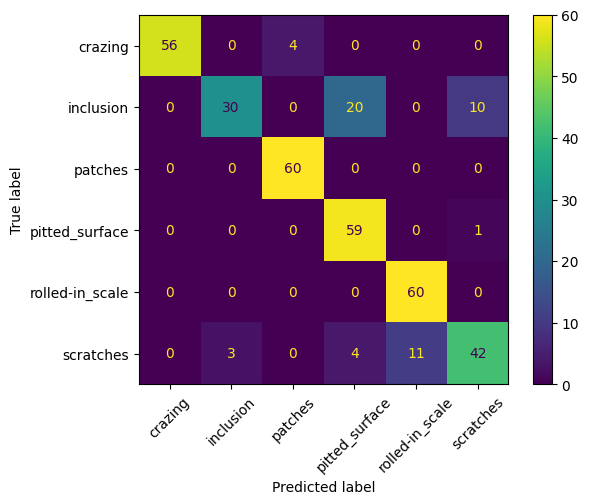

In [69]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_cnn,
    display_labels=class_names
)

disp.plot()
plt.xticks(rotation=45)
plt.show()

## RESNET18

In [22]:
import torch
import torch.nn as nn
from torchvision import models

model = models.resnet18(weights="DEFAULT")

print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\OM/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:04<00:00, 11.3MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [23]:
print(model.fc)

Linear(in_features=512, out_features=1000, bias=True)


In [24]:
model.fc = nn.Linear(512, 6)

print(model.fc)

Linear(in_features=512, out_features=6, bias=True)


In [25]:
for param in model.parameters():
    param.requires_grad = False

In [26]:
for param in model.fc.parameters():
    param.requires_grad = True

In [27]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

fc.weight
fc.bias


In [28]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

In [29]:
num_epochs = 5

for epoch in range(num_epochs):

    model.train()
    running_loss = 0.0

    for images, labels in train_loader:

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")

Epoch [1/5], Loss: 0.9453
Epoch [2/5], Loss: 0.3296
Epoch [3/5], Loss: 0.2174
Epoch [4/5], Loss: 0.1571
Epoch [5/5], Loss: 0.1435


In [30]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 93.33%


In [31]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in val_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.numpy())
        all_predictions.extend(predicted.numpy())

In [32]:
cm = confusion_matrix(all_labels, all_predictions)

print(cm)

[[60  0  0  0  0  0]
 [ 0 41  0  2  0 17]
 [ 0  0 60  0  0  0]
 [ 0  1  0 58  0  1]
 [ 3  0  0  0 57  0]
 [ 0  0  0  0  0 60]]


In [33]:
print(classification_report(
    all_labels,
    all_predictions,
    target_names=class_names
))

                 precision    recall  f1-score   support

        crazing       0.95      1.00      0.98        60
      inclusion       0.98      0.68      0.80        60
        patches       1.00      1.00      1.00        60
 pitted_surface       0.97      0.97      0.97        60
rolled-in_scale       1.00      0.95      0.97        60
      scratches       0.77      1.00      0.87        60

       accuracy                           0.93       360
      macro avg       0.94      0.93      0.93       360
   weighted avg       0.94      0.93      0.93       360



In [34]:
print(cm)

[[60  0  0  0  0  0]
 [ 0 41  0  2  0 17]
 [ 0  0 60  0  0  0]
 [ 0  1  0 58  0  1]
 [ 3  0  0  0 57  0]
 [ 0  0  0  0  0 60]]


In [81]:
resnet_model = model

In [82]:
print(type(resnet_model))

<class 'torchvision.models.mobilenetv2.MobileNetV2'>


### MobileNetV2

In [70]:
import torch
import torch.nn as nn
from torchvision import models

model = models.mobilenet_v2(weights="DEFAULT")

print(model.classifier)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to C:\Users\OM/.cache\torch\hub\checkpoints\mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 21.8MB/s]


Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)


In [71]:
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    6
)

In [72]:
for param in model.features.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

In [73]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

classifier.1.weight
classifier.1.bias


In [74]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.classifier.parameters(),
    lr=0.001
)

In [75]:
num_epochs = 5

for epoch in range(num_epochs):

    model.train()
    running_loss = 0.0

    for images, labels in train_loader:

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")

Epoch [1/5], Loss: 0.9674
Epoch [2/5], Loss: 0.3080
Epoch [3/5], Loss: 0.1979
Epoch [4/5], Loss: 0.1527
Epoch [5/5], Loss: 0.1176


In [76]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"MobileNetV2 Accuracy: {accuracy:.2f}%")

MobileNetV2 Accuracy: 98.61%


In [77]:
from sklearn.metrics import confusion_matrix

mobilenet_labels = []
mobilenet_predictions = []

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        mobilenet_labels.extend(labels.numpy())
        mobilenet_predictions.extend(predicted.numpy())

cm_mobilenet = confusion_matrix(
    mobilenet_labels,
    mobilenet_predictions
)

print("MobileNetV2 Confusion Matrix:")
print(cm_mobilenet)

MobileNetV2 Confusion Matrix:
[[60  0  0  0  0  0]
 [ 0 57  0  0  0  3]
 [ 0  0 59  1  0  0]
 [ 0  0  0 60  0  0]
 [ 0  0  0  0 60  0]
 [ 0  1  0  0  0 59]]


In [78]:
from sklearn.metrics import classification_report

class_names = [
    'crazing',
    'inclusion',
    'patches',
    'pitted_surface',
    'rolled-in_scale',
    'scratches'
]

print(classification_report(
    mobilenet_labels,
    mobilenet_predictions,
    target_names=class_names
))

                 precision    recall  f1-score   support

        crazing       1.00      1.00      1.00        60
      inclusion       0.98      0.95      0.97        60
        patches       1.00      0.98      0.99        60
 pitted_surface       0.98      1.00      0.99        60
rolled-in_scale       1.00      1.00      1.00        60
      scratches       0.95      0.98      0.97        60

       accuracy                           0.99       360
      macro avg       0.99      0.99      0.99       360
   weighted avg       0.99      0.99      0.99       360



In [80]:
print("cnn_model:", 'cnn_model' in globals())
print("resnet_model:", 'resnet_model' in globals())
print("mobilenet_model:", 'mobilenet_model' in globals())

cnn_model: True
resnet_model: False
mobilenet_model: False


In [83]:
print("CNN       :", type(cnn_model).__name__)
print("ResNet18  :", type(resnet_model).__name__)
print("MobileNet :", type(mobilenet_model).__name__)

CNN       : ResNet
ResNet18  : MobileNetV2


NameError: name 'mobilenet_model' is not defined

In [84]:
print(type(cnn_model))
print(type(resnet_model))
print(type(model))

<class 'torchvision.models.resnet.ResNet'>
<class 'torchvision.models.mobilenetv2.MobileNetV2'>
<class 'torchvision.models.mobilenetv2.MobileNetV2'>


In [85]:
import torch.nn as nn

for name, obj in list(globals().items()):
    if isinstance(obj, nn.Module):
        print(name, "→", type(obj).__name__)

model → MobileNetV2
criterion → CrossEntropyLoss
cnn_model → ResNet
resnet_model → MobileNetV2


In [86]:
# Save the currently available models with the correct names
resnet_model = cnn_model
mobilenet_model = model

print("ResNet18:", type(resnet_model).__name__)
print("MobileNetV2:", type(mobilenet_model).__name__)

ResNet18: ResNet
MobileNetV2: MobileNetV2


Demo image found!
Actual      : inclusion
ResNet18    : pitted_surface ❌
MobileNetV2 : inclusion ✅


c:\Users\OM\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\OM\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


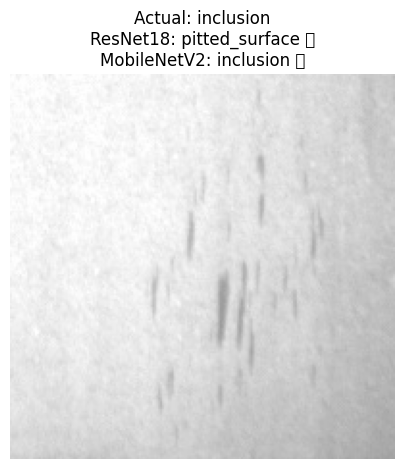

In [87]:
import torch
import matplotlib.pyplot as plt

class_names = [
    'crazing',
    'inclusion',
    'patches',
    'pitted_surface',
    'rolled-in_scale',
    'scratches'
]

resnet_model.eval()
mobilenet_model.eval()

found = False

with torch.no_grad():

    for images, labels in val_loader:

        # ResNet prediction
        resnet_outputs = resnet_model(images)
        resnet_preds = torch.argmax(resnet_outputs, dim=1)

        # MobileNet prediction
        mobilenet_outputs = mobilenet_model(images)
        mobilenet_preds = torch.argmax(mobilenet_outputs, dim=1)

        for i in range(len(labels)):

            actual = labels[i].item()
            resnet_pred = resnet_preds[i].item()
            mobilenet_pred = mobilenet_preds[i].item()

            # We specifically want:
            # Actual = Inclusion
            # ResNet = Wrong
            # MobileNet = Correct

            if (
                actual == class_names.index('inclusion')
                and resnet_pred != actual
                and mobilenet_pred == actual
            ):

                print("Demo image found!")
                print("Actual      :", class_names[actual])
                print("ResNet18    :", class_names[resnet_pred], "❌")
                print("MobileNetV2 :", class_names[mobilenet_pred], "✅")

                # Display image
                image = images[i].permute(1, 2, 0)

                plt.figure(figsize=(5, 5))
                plt.imshow(image)
                plt.axis("off")
                plt.title(
                    f"Actual: {class_names[actual]}\n"
                    f"ResNet18: {class_names[resnet_pred]} ❌\n"
                    f"MobileNetV2: {class_names[mobilenet_pred]} ✅"
                )
                plt.show()

                found = True
                break

        if found:
            break

if not found:
    print("No inclusion image found with this exact prediction pattern.")

### EfficientNet